Whale Species/Vocalizations: ['whale-sounds-mp3', 'whale-sounds-wav']
Number of classes: 2

Dataset loaded successfully!
Total files processed: 22
Total segments extracted: 214
Dataset shape: (214, 128, 128, 1)
Label distribution: [107 107]
Training set size: 171
Test set size: 43

Model Summary:
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 128, 128, 1)]     0         
                                                                 
 conv2d (Conv2D)             (None, 128, 128, 32)      320       
                                                                 
 batch_normalization (BatchN  (None, 128, 128, 32)     128       
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 128, 128, 32)      9248      
                           

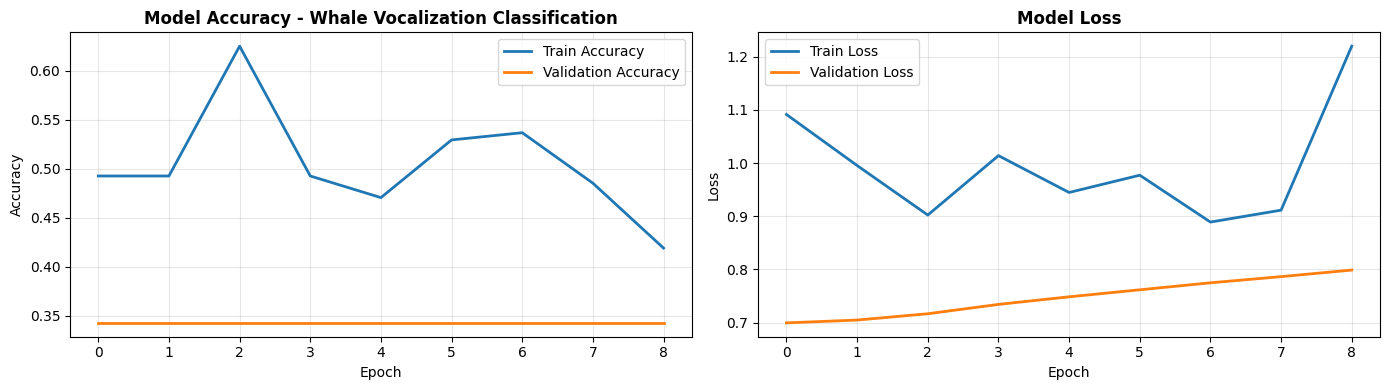


Evaluating on test set...
Test Accuracy: 0.5116
Test Loss: 0.6934

Generating confusion matrix...


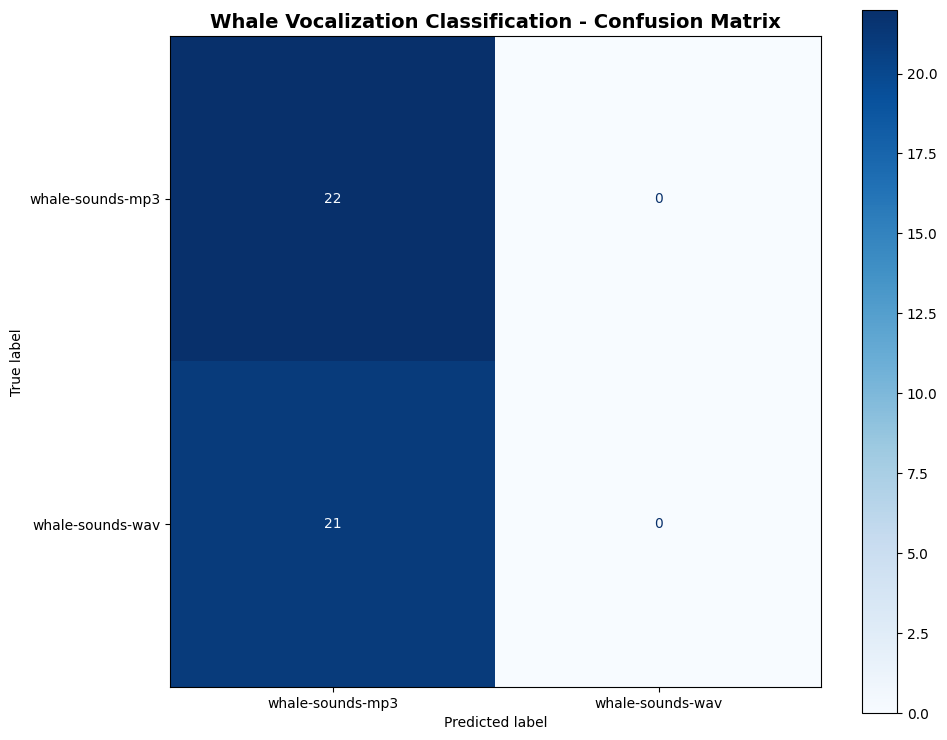


Classification Report:
                  precision    recall  f1-score   support

whale-sounds-mp3       0.51      1.00      0.68        22
whale-sounds-wav       0.00      0.00      0.00        21

        accuracy                           0.51        43
       macro avg       0.26      0.50      0.34        43
    weighted avg       0.26      0.51      0.35        43



c:\Program Files\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Program Files\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Program Files\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from skimage.transform import resize

DATASET_PATH = "data/whale_sounds"  # NOAA whale vocalization recordings
SAMPLE_RATE = 22050
SEGMENT_DURATION = 3  # 3-second segments for whale calls
SAMPLES_PER_SEGMENT = SAMPLE_RATE * SEGMENT_DURATION
IMG_SIZE = (128, 128)

classes = sorted(os.listdir(DATASET_PATH))
class_to_index = {c: i for i, c in enumerate(classes)}

print("Whale Species/Vocalizations:", classes)
print(f"Number of classes: {len(classes)}")

def extract_whale_segments(file_path):
    """
    Extract mel-spectrogram segments from whale vocalization recordings.
    Whale calls often have specific frequency ranges and harmonic structures.
    """
    try:
        signal, sr = librosa.load(file_path, sr=SAMPLE_RATE)
        
        # Handle very short recordings
        if len(signal) < SAMPLES_PER_SEGMENT:
            # Pad short recordings
            signal = np.pad(signal, (0, SAMPLES_PER_SEGMENT - len(signal)), mode='wrap')
        
        segments = []
        
        for start in range(0, len(signal), SAMPLES_PER_SEGMENT):
            end = start + SAMPLES_PER_SEGMENT
            
            if len(signal[start:end]) == SAMPLES_PER_SEGMENT:
                # Mel-spectrogram optimized for whale frequency ranges (0-10kHz typical)
                mel = librosa.feature.melspectrogram(
                    y=signal[start:end],
                    sr=sr,
                    n_mels=128,
                    n_fft=1024,
                    hop_length=512,
                    fmin=0,
                    fmax=sr/2  # Nyquist frequency
                )
                
                # Convert to dB scale
                mel_db = librosa.power_to_db(mel, ref=np.max)
                
                # Normalize to [0, 1] range
                mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-6)
                
                # Resize to standard image size
                mel_img = resize(mel_db, IMG_SIZE)
                
                segments.append(mel_img)
        
        return segments
    
    except Exception as e:
        print(f"Error processing {file_path}: {str(e)}")
        return []

X = []
y = []
file_count = 0
segment_count = 0

for cls in classes:
    folder = os.path.join(DATASET_PATH, cls)
    
    if not os.path.isdir(folder):
        continue
    
    for file in os.listdir(folder):
        path = os.path.join(folder, file)
        
        try:
            segs = extract_whale_segments(path)
            
            for s in segs:
                X.append(s)
                y.append(class_to_index[cls])
                segment_count += 1
            
            if segs:
                file_count += 1
        
        except Exception as e:
            print(f"Skipping: {path} - {str(e)}")
            continue

print(f"\nDataset loaded successfully!")
print(f"Total files processed: {file_count}")
print(f"Total segments extracted: {segment_count}")

X = np.array(X)
y = np.array(y)

X = X.reshape(-1, 128, 128, 1)

# Normalize pixel values to [0, 1]
X = X.astype('float32') / 255.0 if X.max() > 1 else X

print(f"Dataset shape: {X.shape}")
print(f"Label distribution: {np.bincount(y)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

def dilation_block(x, filters, dilation):
    """
    Dilated convolution block for capturing multi-scale temporal patterns
    in whale vocalizations.
    """
    x = layers.Conv2D(
        filters,
        (3, 3),
        padding="same",
        dilation_rate=dilation,
        activation="relu"
    )(x)
    
    x = layers.BatchNormalization()(x)
    
    return x


def build_whale_model(num_classes):
    inp = layers.Input(shape=(128, 128, 1))
    
    x = dilation_block(inp, 32, 1)
    x = dilation_block(x, 32, 2)
    x = layers.MaxPool2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.2)(x)
    
    x = dilation_block(x, 64, 1)
    x = dilation_block(x, 64, 4)
    x = layers.MaxPool2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.2)(x)
    
    x = dilation_block(x, 96, 1)
    x = dilation_block(x, 96, 2)
    
    x = layers.GlobalAveragePooling2D()(x)
    
    x = layers.Dense(192, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    
    x = layers.Dense(96, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    
    out = layers.Dense(num_classes, activation="softmax")(x)
    
    model = models.Model(inp, out)
    
    return model

num_classes = len(classes)
model = build_whale_model(num_classes)

print("\nModel Summary:")
model.summary()

total_params = model.count_params()
print(f"Total parameters: {total_params:,}")
if total_params > 350000:
    print("⚠️  Warning: Model exceeds 350k parameters")
else:
    print("✓ Model within parameter budget")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

logdir = "logs/whale_vocalization_classifier"
os.makedirs(logdir, exist_ok=True)

tb = tf.keras.callbacks.TensorBoard(
    log_dir=logdir,
    histogram_freq=1,
    write_graph=True
)

print("\nTraining whale vocalization classifier...")

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[
        tb,
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=8,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1
        )
    ],
    verbose=1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title("Model Accuracy - Whale Vocalization Classification", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title("Model Loss", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nEvaluating on test set...")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

print("\nGenerating confusion matrix...")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap="Blues", ax=ax)
plt.title("Whale Vocalization Classification - Confusion Matrix", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

from sklearn.metrics import classification_report

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=classes))